# Ridge and Lasso Regression

 Ridge and Lasso regression are some of the simple techniques to reduce model complexity and prevent over-fitting which may result from simple linear regression.




In [1]:
%matplotlib inline
from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn import linear_model
from sklearn.utils import Bunch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
# L2
from sklearn.linear_model import Ridge
# L1
from sklearn.linear_model import Lasso


## load DataSet

In [2]:
try:
    boston = datasets.load_boston()
except ImportError:
    # sklearn 1.2+ ??? load_boston???????????????????????????? Ridge/Lasso ????????
    rng = np.random.default_rng(42)
    feature_names = np.array([
        'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
        'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
    ])
    data = rng.normal(size=(506, len(feature_names)))
    true_coef = np.array([-1.1, 0.7, -0.4, 1.8, -1.2, 4.0, -0.5,
                          -1.6, 0.9, -0.8, -1.9, 0.5, -3.2])
    target = 22 + data @ true_coef + rng.normal(scale=2.5, size=data.shape[0])
    target = np.maximum(target, 5)
    boston = Bunch(
        data=data,
        target=target,
        feature_names=feature_names,
        filename='synthetic_boston_like_dataset',
        DESCR='Synthetic Boston-like dataset for sklearn 1.2+ compatibility.'
    )

boston_df = pd.DataFrame(boston.data, columns=boston.feature_names)
boston_df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,-0.016801,-0.853044,0.879398,0.777792,0.066031
1,1.127241,0.467509,-0.859292,0.368751,-0.958883,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529,-0.428328,-0.352134
2,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,-0.824481
3,0.650593,0.743254,0.543154,-0.665510,0.232161,0.116686,0.218689,0.871429,0.223596,0.678914,0.067579,0.289119,0.631288
4,-1.457156,-0.319671,-0.470373,-0.638878,-0.275142,1.494941,-0.865831,0.968278,-1.682870,-0.334885,0.162753,0.586222,0.711227


## 波士頓房價

檔案中包含506條樣本資料，即有506條房價資料，而13表示有13個影響房價的特徵值
特徵值解釋如下表
![波士頓房價檔案部分中英文標題](images/boston_1.png)

In [3]:
print("資料包內含資料的key值：", boston.keys())
print("資料欄位名稱(資料特徵參數)：",boston.feature_names)
print("檔案位置:",boston['filename'])
print("第一筆資料:",boston.data[:1])
print("資料型別:",type(boston.data))


target_names = boston.target
print("資料size:",boston['data'].size)
print("前10筆target_names(房價): ", boston['target'][:10])
#print(boston.target)


#組成 pandas DataFrame (資料表的方式顯示)
x = pd.DataFrame(boston['data'], columns=boston['feature_names'])
print("pandas DataFrame\n",x.head(5),sep='')

資料包內含資料的key值： dict_keys(['data', 'target', 'feature_names', 'filename', 'DESCR'])
資料欄位名稱(資料特徵參數)： ['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']
檔案位置: synthetic_boston_like_dataset
第一筆資料: [[ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519 -1.30217951
   0.1278404  -0.31624259 -0.01680116 -0.85304393  0.87939797  0.77779194
   0.0660307 ]]
資料型別: <class 'numpy.ndarray'>
資料size: 6578
前10筆target_names(房價):  [15.07080597 27.91942784 16.85654509 15.61111475 24.47738666 19.11688845
 14.84247004  8.67792321 15.72486438 24.76711233]
pandas DataFrame
       CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
0  0.304717 -1.039984  0.750451  0.940565 -1.951035 -1.302180  0.127840   
1  1.127241  0.467509 -0.859292  0.368751 -0.958883  0.878450 -0.049926   
2  0.532309  0.365444  0.412733  0.430821  2.141648 -0.406415 -0.512243   
3  0.650593  0.743254  0.543154 -0.665510  0.232161  0.116686  0.218689   
4 -1.457156 -0.319671 -0.47

In [4]:
import pandas as pd
x = pd.DataFrame(boston['data'], columns=boston['feature_names'])
y = pd.DataFrame(boston['target'],columns=['target'])

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=3)
print(len(X_test), len(y_test))

print(len(X_train), len(y_train))

152 152
354 354


In [5]:
x.shape

(506, 13)

## Create a Ridge Regression
       shrinking coefficient magnitude using Ridge regression
       
###   Ridge (L2 norm)
![image.png](https://miro.medium.com/max/1374/1*hAGhQehrqAmT1pvz3q4t8Q.png)
 
![image.png](https://miro.medium.com/max/670/1*sC4KLMHU0j_1gR3VmlgGtg.png)


In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

rr = Ridge(alpha=0.01) # higher the alpha value, more restriction on the coefficients; low alpha > more generalization, coefficients are barely
# restricted and in this case linear and ridge regression resembles
rr.fit(X_train, y_train)

rr100 = Ridge(alpha=100) #  comparison with alpha value
rr100.fit(X_train, y_train)

train_score=lr.score(X_train, y_train)
test_score=lr.score(X_test, y_test)

Ridge_train_score = rr.score(X_train,y_train)
Ridge_test_score = rr.score(X_test, y_test)

Ridge_train_score100 = rr100.score(X_train,y_train)
Ridge_test_score100 = rr100.score(X_test, y_test)

print("linear regression train score:", train_score)
print("linear regression test score:", test_score)
print("ridge regression train score low alpha:", Ridge_train_score)
print("ridge regression test score low alpha:", Ridge_test_score)
print("ridge regression train score high alpha:", Ridge_train_score100)
print("ridge regression test score high alpha:", Ridge_test_score100)


linear regression train score: 0.8705209656069242
linear regression test score: 0.8333977383486753
ridge regression train score low alpha: 0.8705209649840779
ridge regression test score low alpha: 0.8333963474845725
ridge regression train score high alpha: 0.8321150388903771
ridge regression test score high alpha: 0.7853184196718153


In [7]:
rr.coef_

array([-1.16895524,  0.65191783, -0.34228608,  1.64945691, -1.13074768,
        3.80730634, -0.34946179, -1.76156106,  0.86493383, -0.98521071,
       -1.88952446,  0.55056231, -3.07419278])

In [8]:
type(rr.coef_)
np.ravel(rr.coef_)


array([-1.16895524,  0.65191783, -0.34228608,  1.64945691, -1.13074768,
        3.80730634, -0.34946179, -1.76156106,  0.86493383, -0.98521071,
       -1.88952446,  0.55056231, -3.07419278])


### $\alpha$ 愈小則等同於Linear Regression; $\alpha$ 愈大則會限制$\omega$ 的值。<br>這將使得在一定iteration下不一定能找到最低值, 即loss是增加的

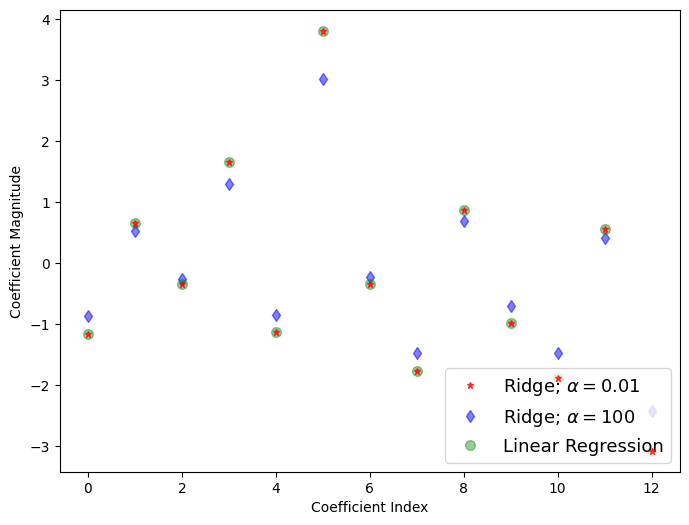

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(np.ravel(rr.coef_),alpha=0.7,linestyle='none',marker='*',markersize=5,color='red',label=r'Ridge; $\alpha = 0.01$',zorder=7) # zorder for ordering the markers # zorder for ordering the markers
plt.plot(np.ravel(rr100.coef_),alpha=0.5,linestyle='none',marker='d',markersize=6,color='blue',label=r'Ridge; $\alpha = 100$') # alpha here is for transparency
plt.plot(np.ravel(lr.coef_),alpha=0.4,linestyle='none',marker='o',markersize=7,color='green',label='Linear Regression')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Magnitude')
plt.legend(fontsize=13,loc=4)
plt.show()

## Create a Lasso Regression


### Lasso (L1 norm)
 ![image.png](https://miro.medium.com/max/1402/1*P5Lq5mAi4WAch7oIeiS3WA.png)
 
 ![image.png](https://miro.medium.com/max/949/1*JH9eAS2I9mwOpuFLg-gD6g.png)


In [10]:
lasso = Lasso(alpha=1) #default alpha=1
lasso.fit(X_train,y_train)
train_score=lasso.score(X_train,y_train)
test_score=lasso.score(X_test,y_test)

coeff_used = np.sum(lasso.coef_!=0)
print("training score:", train_score )
print("test score: ", test_score)
#Lasso(alpha=0.01)
print("number of features used: ", coeff_used)
print(lasso)

training score: 0.675073654355469
test score:  0.5858290249850391
number of features used:  7
Lasso(alpha=1)


In [11]:
lasso.coef_

array([-0.10470037,  0.        , -0.        ,  0.66832895, -0.05182517,
        2.89166771, -0.        , -0.91297715,  0.        , -0.        ,
       -0.94847403,  0.        , -2.07715163])

In [12]:
#Lasso(alpha=0.01)
lasso001 = Lasso(alpha=0.01, max_iter=1000000)
lasso001.fit(X_train,y_train)
train_score001=lasso001.score(X_train,y_train)
test_score001=lasso001.score(X_test,y_test)
coeff_used001 = np.sum(lasso001.coef_!=0)
print("training score for alpha=0.01:", train_score001 )
print("test score for alpha =0.01: ", test_score001)
print("number of features used: for alpha =0.01:", coeff_used001)
print('-'*20)
#Lasso(alpha=0.0001)
lasso00001 = Lasso(alpha=0.0001, max_iter=1000000)
lasso00001.fit(X_train,y_train)
train_score00001=lasso00001.score(X_train,y_train)
test_score00001=lasso00001.score(X_test,y_test)
coeff_used00001 = np.sum(lasso00001.coef_!=0)
print("training score for alpha=0.0001:", train_score00001)
print("test score for alpha =0.0001: ", test_score00001)
print("number of features used: for alpha =0.0001:", coeff_used00001)

#LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
lr_train_score=lr.score(X_train,y_train)
lr_test_score=lr.score(X_test,y_test)
print('-'*20)
print("LR training score:", lr_train_score)
print("LR test score: ", lr_test_score)

training score for alpha=0.01: 0.8704920613517233
test score for alpha =0.01:  0.8329944486513058
number of features used: for alpha =0.01: 13
--------------------
training score for alpha=0.0001: 0.8705209627029508
test score for alpha =0.0001:  0.8333940454010014
number of features used: for alpha =0.0001: 13
--------------------
LR training score: 0.8705209656069242
LR test score:  0.8333977383486753



### $\alpha$=0.01 會比$\alpha$=0.1 使$\omega$ 更小<br> 若$\omega$ 很小等於Linear regression 這將使得在一定iteration下不一定能找到最低值, 即loss是增加的

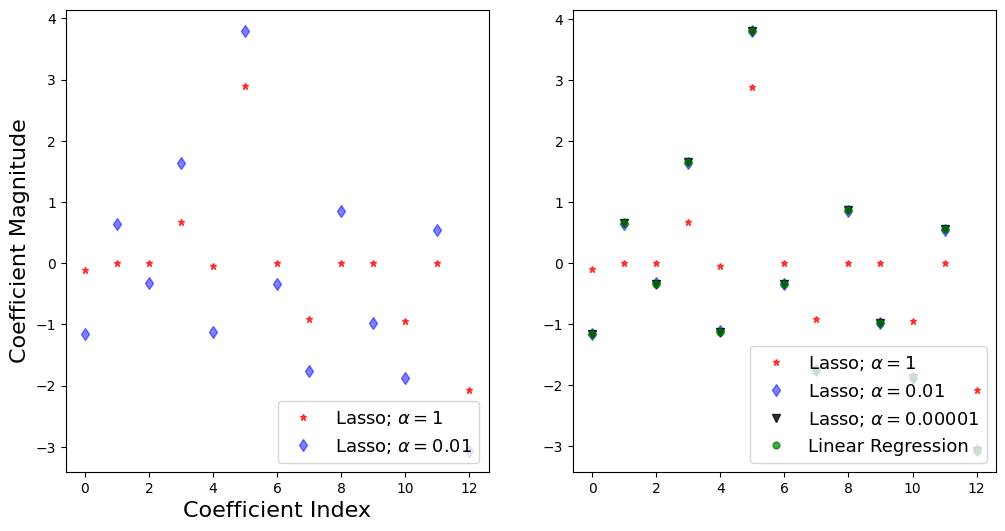

In [13]:
plt.figure(figsize=(12, 6),)
plt.subplot(1,2,1)
plt.plot(lasso.coef_,alpha=0.7,linestyle='none',marker='*',markersize=5,color='red',label=r'Lasso; $\alpha = 1$',zorder=7) # alpha here is for transparency
plt.plot(lasso001.coef_,alpha=0.5,linestyle='none',marker='d',markersize=6,color='blue',label=r'Lasso; $\alpha = 0.01$') # alpha here is for transparency

plt.xlabel('Coefficient Index',fontsize=16)
plt.ylabel('Coefficient Magnitude',fontsize=16)
plt.legend(fontsize=13,loc=4)
plt.subplot(1,2,2)
plt.plot(lasso.coef_,alpha=0.7,linestyle='none',marker='*',markersize=5,color='red',label=r'Lasso; $\alpha = 1$',zorder=7) # alpha here is for transparency
plt.plot(lasso001.coef_,alpha=0.5,linestyle='none',marker='d',markersize=6,color='blue',label=r'Lasso; $\alpha = 0.01$') # alpha here is for transparency
plt.plot(lasso00001.coef_,alpha=0.8,linestyle='none',marker='v',markersize=6,color='black',label=r'Lasso; $\alpha = 0.00001$') # alpha here is for transparency
plt.plot(np.ravel(lr.coef_),alpha=0.7,linestyle='none',marker='o',markersize=5,color='green',label='Linear Regression',zorder=2)

plt.legend(fontsize=13,loc=4)

plt.show()

愈高維度時, Lassso 愈有機會只使用部份特徵(部份切面)來找到低點, 而Ridge像球體一樣無法只用部份特徵才找到最低點

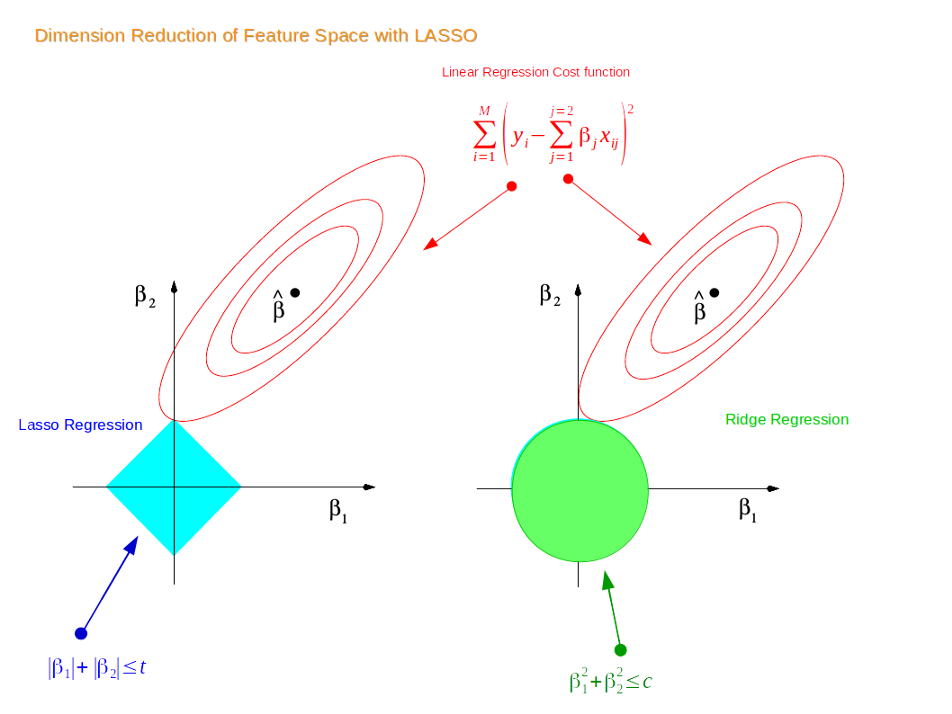

## R2 Score 

In [14]:
from sklearn.metrics import r2_score
#R2 square
r2_score(y_test,rr100.predict(X_test))

0.7853184196718153

In [15]:
# ???????????? R2 score
models = {
    'Linear Regression': lr,
    'Ridge alpha=0.01': rr,
    'Ridge alpha=100': rr100,
    'Lasso alpha=1': lasso,
    'Lasso alpha=0.01': lasso001,
    'Lasso alpha=0.0001': lasso00001,
}

for name, estimator in models.items():
    score = r2_score(y_test, estimator.predict(X_test))
    print(f'{name}: {score:.4f}')


Linear Regression: 0.8334
Ridge alpha=0.01: 0.8334
Ridge alpha=100: 0.7853
Lasso alpha=1: 0.5858
Lasso alpha=0.01: 0.8330


Lasso alpha=0.0001: 0.8334
